# Bilby TGR (TIGER) - Parameter Estimation Tutorial

```bilby_tgr``` is an extension of ```bilby```, allowing tests of GR on gravitational wave data via stochastic sampling on (typically) agnostic deviation parameters. ```bilby_tgr``` currently allows for the following tests:

- $\textbf{TIGER}$
- FTI
- Spin Indiced Quadrupole Moments (siqm)
- Modified Dispersion Relations (mdr)
- Spacetime Symmetry Breaking (ssb)
- Parametrised SEOB (pSEOB)

We will focus on the TIGER test, an inspiral only test of GR which implements deviations systematically to the waveform phase at various PN orders. In GR, the frequency domain waveform phase (in the SPA) is known to 3.5PN order:

\begin{equation}
       \Psi_\mathrm{\ell m}^\mathrm{GR}(f) = 2\pi f t_c - \varphi_c - \frac{\pi}{4} + \frac{3}{128\eta v^5}\frac{m}{2} \sum_{n=0}^7 \left( \psi_{n}^\mathrm{GR} + \psi_{n(l)}^\mathrm{GR} \mathrm{log}v \right)v^n
\end{equation}

where $v = (2\pi M f / m )^{1/3}$ is the binary velocity. Typically, extensions/modifications of GR lead to a dephasing of the waveform with respect to GR. The presence of additional physics leads to extra terms in the waveform phase that modify the GR prediction, potentially including dipolar terms at lower PN orders than the leading GR term. In other words, we can add absolute corrections to $\Psi_\mathrm{GR}(f)$ as:

\begin{equation}
       \Psi_\mathrm{\ell m}(f) = \Psi_\mathrm{\ell m}^\mathrm{GR}(f) + \delta\Psi_\mathrm{\ell m}(f)
\end{equation}

with 

\begin{equation}
       \delta\Psi_\mathrm{\ell m}(f) = \frac{3}{128\eta v^5}\frac{m}{2} \sum_{n=-2}^7 \delta\psi_{n}v^n
\end{equation}

Note, one can also choose a different convention where fractional deviations are considered, $\Psi_\mathrm{\ell m}(f) = \Psi_\mathrm{\ell m}^\mathrm{GR}(f)\left[1 + \delta\Psi(f)_\mathrm{\ell m}\right]$, with terms at lower PN orders than GR added as absolute deviations.

We will focus on $\textbf{absolute deviations}$, where the full waveform phase goes as

\begin{equation}
       \Psi_\mathrm{\ell m}(f) \sim \frac{3}{128\eta v^5}\frac{m}{2} \sum_{n=-2}^7 \left( \psi_n + \psi_{n(l)} \mathrm{log}v \right)v^{n}
\end{equation}

where at each PN order the GR contribution to the phase is modified as:

\begin{align}
       \psi_n &= \psi_{n}^\mathrm{GR} + \delta\psi_{n} \;\; \forall n \in \{0, 1, 2, ...\} \\
       \psi_{n(l)} &= \psi_{n(l)}^\mathrm{GR} + \delta\psi_{n(l)} \;\; \forall n \in \{0, 1, 2, ...\}
\end{align}

while lower PN terms relative to GR are added as:

\begin{equation}
       \psi_n = \delta\psi_{n} \;\; \forall n \in \{-2, -1\}.
\end{equation}

The TIGER implementation in ```bilby_tgr``` allows us to add these agnostic parameters to a baseline GR waveform (here we will use IMRPhenomXPHM), which can then be sampled using your favourite sampler to obtain posteriors on these parameters. Stating the obvious, if GR is correct we should expect $\delta\psi_n = \delta\psi_{n(l)} = 0 \;\; \forall n$.

## Import Packages

The main packages we need are:

- ```bilby```
- ```bilby_tgr```

In [1]:
# This is to suppress a SWIG warning when import lal via bilby
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import bilby
import bilby_tgr

# Some standard imports
import numpy as np
#from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
        'axes.grid': False,
        'axes.labelsize': 12,
        'axes.linewidth': 0.8,
        'axes.titlesize': 12,
        'font.size': 16,
        'legend.fontsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'font.family': 'serif',
        'font.sans-serif': ['Bitstream Vera Sans'],
        'font.serif': ['Times New Roman'],
        'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
        'text.usetex': True,
        'patch.force_edgecolor': True,
        'figure.dpi': 500,
        'savefig.dpi': 1000,
    }
)

## Beyond GR Signals

We'll start by generating a beyond GR signal from a BBH system using the ```lal_binary_black_hole_TIGER_PhenomX``` function.

In [3]:
?bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX

Signature:
bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(
    frequency_array,
    mass_1,
    mass_2,
    luminosity_distance,
    a_1,
    tilt_1,
    phi_12,
    a_2,
    tilt_2,
    phi_jl,
    theta_jn,
    phase,
    dchi_minus2,
    dchi_minus1,
    dchi_0,
    dchi_1,
    dchi_2,
    dchi_3,
    dchi_4,
    dchi_5l,
    dchi_6,
    dchi_6l,
    dchi_7,
    db_1,
    db_2,
    db_3,
    db_4,
    dc_1,
    dc_2,
    dc_4,
    dc_l,
    **kwargs,
)
Docstring:
A binary black hole waveform using lalsimulation with
parameterized corrections in the TIGER framework. This
interface supports the deviation in PN coefficients and
the PhenomX post-inspiral coefficients: db_1, db_2, db_3,
db_4, dc_1, dc_2, dc_4, dc_l.
PhenomX supports the -1PN coefficient and -0.5PN coefficient.
Recommended waveform models: IMRPhenomXAS, IMRPhenomXP,
IMRPhenomXHM, IMRPhenomXPHM.
----------
Parameters
----------
frequency_array: array_like
    The frequencies at which we want to calculate the st

### Constraining $\delta\psi_n$ with low/high mass signals

For simplicity, we'll only consider the effect of $\delta\psi_{-2}$ and so we'll set all other beyond GR parameters to zero. The $\delta\psi_{-2}$ coefficient is the leading order correction, related to the low frequency/velocity part of the signal

\begin{equation}
    \delta\Psi(f) \sim v^{-5} (\delta\psi_{-2}v^{-2} + \delta\psi_0 + \delta\psi_{1}v + \delta\psi_{2}v^2 + \mathcal{O}(v^3)).
\end{equation}

and so will be the dominant correction during the early inspiral, with higher order corrections becoming important at later times. Long inspiral signals (i.e. low mass / high mass ratio) will allow for tighter constraints on beyond GR parameters, as minor phase corrections will accumulate over time. 

However, parameter estimation runs on long signals are too expensive for a laptop, so we're stuck with shorter (high mass) signals for now. Fortunately, we can still obtain reasonable constraints on $\delta\psi_{-2}$.

Let's now define a set of binary parameters that we will use to generate an injection signal:

In [4]:
# Frequencies at which we want to evaluate the waveform (20 Hz to 2000 Hz)
frequency_array = np.logspace(np.log10(20), np.log10(2000), 20001)

injection_parameters = dict(
    mass_1 = 50,
    mass_2 = 40,
    luminosity_distance = 1e3,
    a_1 = 0.0,
    tilt_1 = 0.0,
    phi_12 = 0.0,
    a_2 = 0.0,
    tilt_2 = 0.0,
    phi_jl = 0.0,
    theta_jn = 0.0,
    phase = 0.0,
    
    # Beyond GR parameters 

    # Inspiral coefficients
    dchi_minus2 = 0.0,
    dchi_minus1 = 0.0,
    dchi_0 = 0.0,
    dchi_1 = 0.0,
    dchi_2 = 0.0,
    dchi_3 = 0.0,
    dchi_4 = 0.0,
    dchi_5l = 0.0,
    dchi_6 = 0.0,
    dchi_6l = 0.0,
    dchi_7 = 0.0,
    # Intermediate coefficients
    db_1 = 0.0,
    db_2 = 0.0,
    db_3 = 0.0,
    db_4 = 0.0,
    # MR coefficients
    dc_1 = 0.0,
    dc_2 = 0.0,
    dc_4 = 0.0,
    dc_l = 0.0
)

Let's take a look at how these corrections manifest in the waveform for low/high mass systems. For this, we'll consider the following parameters:

High Mass:
- $m_1 = 50 M_\odot$
- $m_2 = 40 M_\odot$
- $\delta\psi_{-2} = 0.05$
- $\delta\psi_{-2} = 0.005$

Low Mass:
- $m_1 = 8 M_\odot$
- $m_2 = 4 M_\odot$
- $\delta\psi_{-2} = 0.001$
- $\delta\psi_{-2} = 0.0001$

We'll copy the previous injection parameters, but leave them unchanged for later.

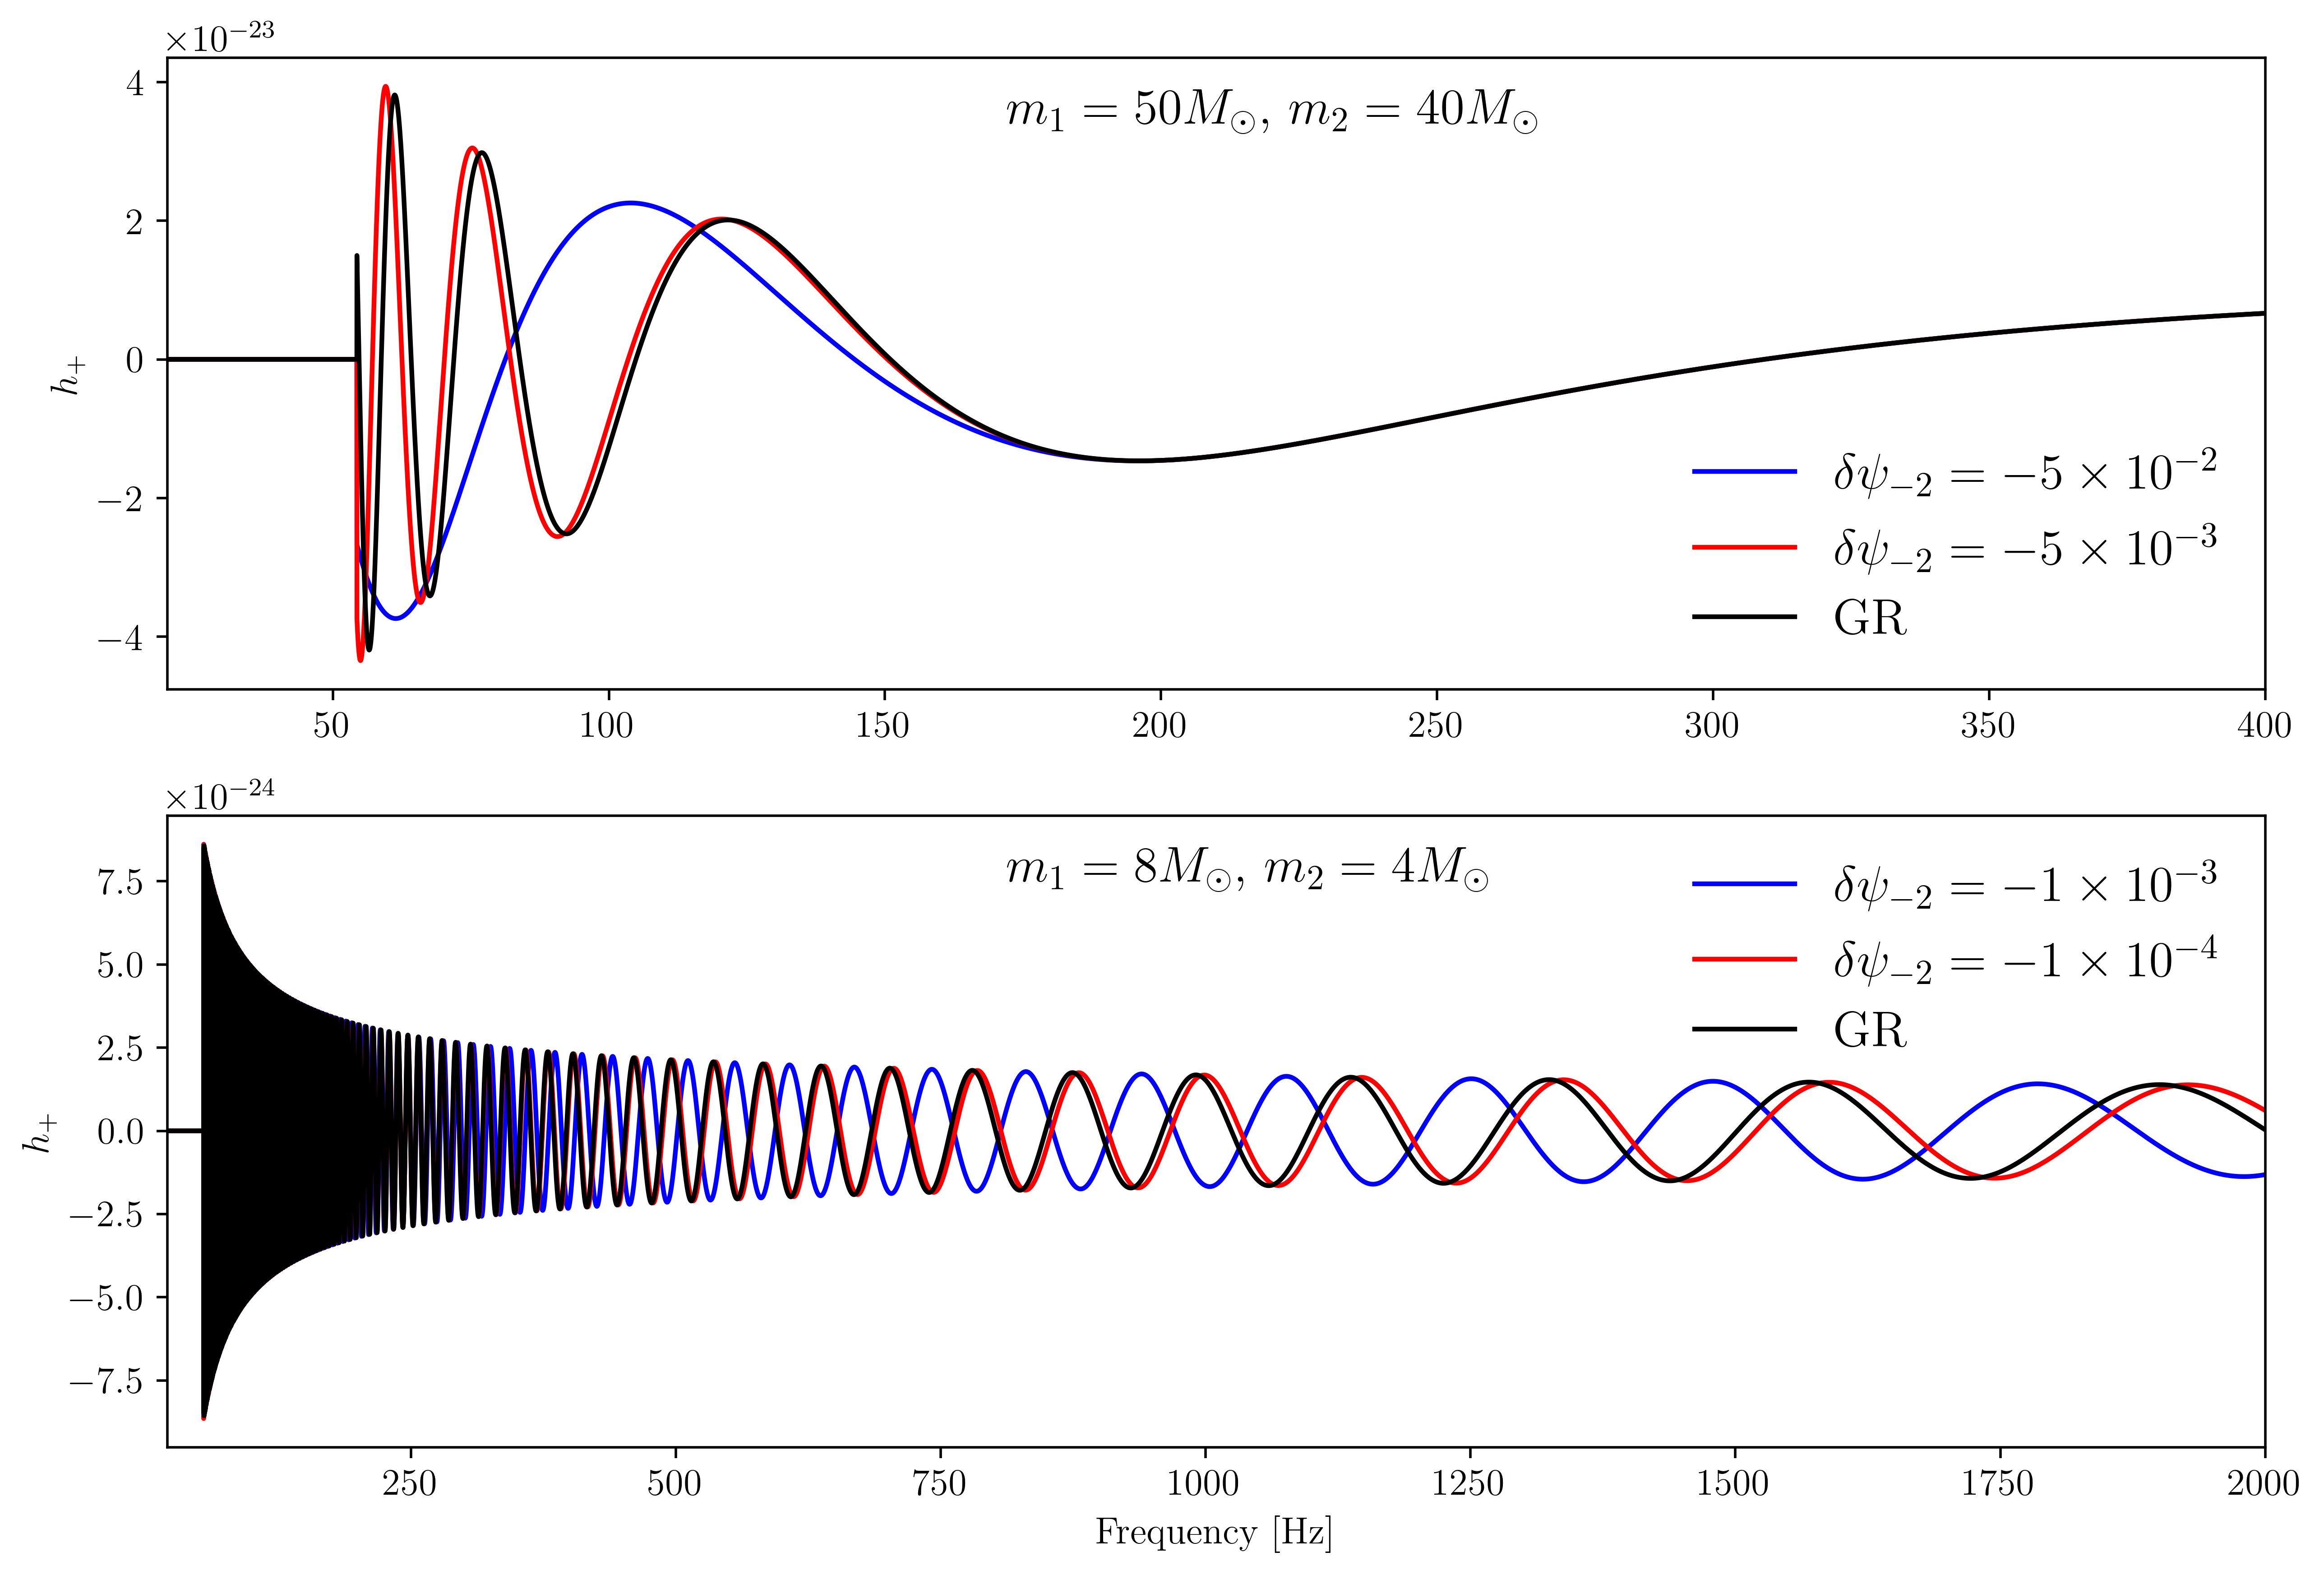

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

high_mass_params = injection_parameters.copy()
high_mass_params["dchi_minus2"] = -0.05
high_mass_params_low = high_mass_params.copy()
high_mass_params_low["dchi_minus2"] = -0.005

high_mass_params_gr = high_mass_params.copy()
high_mass_params_gr["dchi_minus2"] = 0.0 

""" Create signals using TIGER PhenomX waveform """
injection_signal = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **high_mass_params)
injection_signal_low = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **high_mass_params_low)
injection_signal_gr = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **high_mass_params_gr)

axes[0].plot(frequency_array,np.real(injection_signal['plus']), c='b', alpha=1.0, label=r'$\delta\psi_{-2} = -5\times 10^{-2}$')
axes[0].plot(frequency_array,np.real(injection_signal_low['plus']), c='r', alpha=1.0, label=r'$\delta\psi_{-2} = -5\times 10^{-3}$')
axes[0].plot(frequency_array,np.real(injection_signal_gr['plus']), c='k', alpha=1.0, label='GR')
text = (f"$m_1={injection_parameters['mass_1']}M_\\odot$, $m_2={injection_parameters['mass_2']}M_\\odot$\n")
axes[0].text(0.4, 0.95, text, transform=axes[0].transAxes, fontsize=16, va='top', ha='left')

""" Now let's see what the same deviation looks like in a low mass system """
low_mass_params = injection_parameters.copy()
low_mass_params["dchi_minus2"] = -0.001
low_mass_params["mass_1"] = 8
low_mass_params["mass_2"] = 4
low_mass_params_low = low_mass_params.copy()
low_mass_params_low["dchi_minus2"] = -0.0001
low_mass_params_gr = low_mass_params.copy()
low_mass_params_gr["dchi_minus2"] = 0.0

injection_signal = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **low_mass_params)
injection_signal_low = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **low_mass_params_low)
injection_signal_gr = bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX(frequency_array, **low_mass_params_gr)

axes[1].plot(frequency_array,np.real(injection_signal['plus']), c='b', alpha=1.0, label=r'$\delta\psi_{-2} = -1\times 10^{-3}$')
axes[1].plot(frequency_array,np.real(injection_signal_low['plus']), c='r', alpha=1.0, label=r'$\delta\psi_{-2} = -1\times 10^{-4}$')
axes[1].plot(frequency_array,np.real(injection_signal_gr['plus']), c='k', alpha=1.0, label='GR')
text = (f"$m_1={low_mass_params['mass_1']}M_\\odot$, $m_2={low_mass_params['mass_2']}M_\\odot$\n")
axes[1].text(0.4, 0.95, text, transform=axes[1].transAxes, fontsize=16, va='top', ha='left')

axes[0].set_xlim(20,400)
axes[1].set_xlim(20,2000)

axes[0].legend(frameon=False)
axes[1].legend(frameon=False)

axes[1].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('$h_{+}$')
axes[1].set_ylabel('$h_{+}$')
plt.show()

For our low mass event, the inspiral is long and so the effects of $\delta\chi_{-2}$ manifest nicely, (in contrast to our high mass event). Clearly, the mismatch between a GR signal and a beyond GR signal in the low mass case will be high when $\delta\psi_{-2}^\mathrm{Low Mass} \lesssim 10^{-4}$, while in the high mass case, this will be $\delta\psi_{-2}^\mathrm{High Mass} \lesssim 5 \times 10^{-3}$, using the examples above. In any case, this is an order of magnitude difference on the contraints.

## Injection and Recovery with ```Bilby```

Now let's injection and recover a beyond GR signal with the same waveform generator, ```lal_binary_black_hole_TIGER_PhenomX```.

In [6]:
""" Label of run, and output directory for all the data/results."""

outdir = "outdir"
label = "dchi_minus2_injection"

""" Set up bilby logger to capture output messages in a .log file in the outdir. """
bilby.core.utils.setup_logger(outdir=outdir, label=label)
logger = bilby.core.utils.logger

We need to specify a few parameters:

- Duration [s] - this needs to as large as the duration of the longest signal as dictated by the priors (to be chosen later).
- Sampling Frequency [Hz]
- Geocent Time [s]

We can also include some additional waveform arguments (e.g. waveform approximant, min/max frequencies, etc.).

### Waveform Generation

In [7]:
duration = 4
sampling_frequency = 2048
geocent_time = 1e9
waveform_arguments = dict(waveform_approximant = 'IMRPhenomXPHM')

Now, we set up a ```WaveformGenerator``` with these parameters. We need to feed in the duration of our signal, the sampling frequency, the source model we wish to use (here we want ```lal_binary_black_hole_TIGER_PhenomX```), and any additional arguments present in our ```waveform_arguments``` dictionary.

In [8]:
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX,
    waveform_arguments=waveform_arguments
)

19:51 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=0, frequency_domain_source_model=bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXPHM'})


### Interferometers

Next, we need to construct our detector network. Here, we are using Hanford and Livingston detectors, which are added to the ```InterferometerList``` class. This allows us to iteratate over all interferometers when we want to inject signals, etc. We then set the min and max frequencies of each detector, after which we can inject signals.

Here, we inject our signal into a zero-noise realisation. So to construct the noise realisation we use ```set_strain_data_from_zero_noise``` (alternatively, we can use ```set_strain_data_from_power_spectral_density``` if we want a a Gaussian noise realisation scaled with the PSD).

Using the ```inject_signal``` method, we can feed the injection signal into out detectors 

In [9]:
interferometers = bilby.gw.detector.InterferometerList(["H1", "L1"])
for interferometer in interferometers:
    interferometer.minimum_frequency = 20
    interferometer.maximum_frequency = 2000

""" Here we determine the start time by taking the time of peak strain, add some small time buffer for the post-merger signal, and then subtracting the total duration."""
start_time = geocent_time + 0.5 - duration
interferometers.set_strain_data_from_zero_noise(sampling_frequency=sampling_frequency, duration=duration, start_time=start_time)

injection_parameters['geocent_time'] = geocent_time
injection_parameters['ra'] = 0.0
injection_parameters['dec'] = 0.0
injection_parameters['psi'] = 0.0

interferometers.inject_signal(parameters=injection_parameters, waveform_generator=waveform_generator)

print(interferometers.meta_data)

19:51 bilby INFO    : Injected signal in H1:
19:51 bilby INFO    :   optimal SNR = 14.75
19:51 bilby INFO    :   matched filter SNR = 14.75-0.00j
19:51 bilby INFO    :   mass_1 = 50
19:51 bilby INFO    :   mass_2 = 40
19:51 bilby INFO    :   luminosity_distance = 1000.0
19:51 bilby INFO    :   a_1 = 0.0
19:51 bilby INFO    :   tilt_1 = 0.0
19:51 bilby INFO    :   phi_12 = 0.0
19:51 bilby INFO    :   a_2 = 0.0
19:51 bilby INFO    :   tilt_2 = 0.0
19:51 bilby INFO    :   phi_jl = 0.0
19:51 bilby INFO    :   theta_jn = 0.0
19:51 bilby INFO    :   phase = 0.0
19:51 bilby INFO    :   dchi_minus2 = 0.0
19:51 bilby INFO    :   dchi_minus1 = 0.0
19:51 bilby INFO    :   dchi_0 = 0.0
19:51 bilby INFO    :   dchi_1 = 0.0
19:51 bilby INFO    :   dchi_2 = 0.0
19:51 bilby INFO    :   dchi_3 = 0.0
19:51 bilby INFO    :   dchi_4 = 0.0
19:51 bilby INFO    :   dchi_5l = 0.0
19:51 bilby INFO    :   dchi_6 = 0.0
19:51 bilby INFO    :   dchi_6l = 0.0
19:51 bilby INFO    :   dchi_7 = 0.0
19:51 bilby INFO   

{'H1': {'name': 'H1', 'optimal_SNR': np.float64(14.751774853744474), 'matched_filter_SNR': np.complex128(14.751774853744475-3.976924344042307e-18j), 'parameters': {'mass_1': 50, 'mass_2': 40, 'luminosity_distance': 1000.0, 'a_1': 0.0, 'tilt_1': 0.0, 'phi_12': 0.0, 'a_2': 0.0, 'tilt_2': 0.0, 'phi_jl': 0.0, 'theta_jn': 0.0, 'phase': 0.0, 'dchi_minus2': 0.0, 'dchi_minus1': 0.0, 'dchi_0': 0.0, 'dchi_1': 0.0, 'dchi_2': 0.0, 'dchi_3': 0.0, 'dchi_4': 0.0, 'dchi_5l': 0.0, 'dchi_6': 0.0, 'dchi_6l': 0.0, 'dchi_7': 0.0, 'db_1': 0.0, 'db_2': 0.0, 'db_3': 0.0, 'db_4': 0.0, 'dc_1': 0.0, 'dc_2': 0.0, 'dc_4': 0.0, 'dc_l': 0.0, 'geocent_time': 1000000000.0, 'ra': 0.0, 'dec': 0.0, 'psi': 0.0}}, 'L1': {'name': 'L1', 'optimal_SNR': np.float64(19.269599518338335), 'matched_filter_SNR': np.complex128(19.269599518338335-2.3268217449997974e-18j), 'parameters': {'mass_1': 50, 'mass_2': 40, 'luminosity_distance': 1000.0, 'a_1': 0.0, 'tilt_1': 0.0, 'phi_12': 0.0, 'a_2': 0.0, 'tilt_2': 0.0, 'phi_jl': 0.0, 'theta_

### Priors

Now we need to define our priors. Since we know the parameters of the injected signal, we can use relatively narrow priors. To set the priors in bilby, we create a dictionary which then gets passed to the BBHPriorDict class instance.

Since we don't want to sample over most of the deviation parameters, we set the priors to 0.

In [10]:
chirp_mass = ((injection_parameters['mass_1']*injection_parameters['mass_2'])**(3/5))/((injection_parameters['mass_1']+injection_parameters['mass_2'])**(1/5))
mass_ratio = injection_parameters['mass_2']/injection_parameters['mass_1']

print(f"Chirp Mass: {chirp_mass:.2f}")
print(f"Mass Ratio: {mass_ratio}")

prior_dict = dict(chirp_mass = bilby.gw.prior.UniformInComponentsChirpMass(minimum=20, maximum=50, name='chirp_mass'), 
            mass_ratio = bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.1, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None), 
            a_1 = bilby.gw.prior.Uniform(minimum=0, maximum=0.5, name='a_1', latex_label='$a_1$', unit=None), 
            a_2 = bilby.gw.prior.Uniform(minimum=0, maximum=0.5, name='a_2', latex_label='$a_2$', unit=None), 
            tilt_1 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='tilt_1'), 
            tilt_2 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='tilt_2'), 
            phi_12 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phi_12', boundary='periodic'), 
            phi_jl = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phi_jl', boundary='periodic'), 
            luminosity_distance = bilby.gw.prior.PowerLaw(alpha=2, minimum=1e2, maximum=1e4, name='luminosity_distance', latex_label='$d_L$', unit='Mpc'), 
            theta_jn = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='theta_jn'), 
            psi = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='psi', boundary='periodic'), 
            phase = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phase', boundary='periodic'), 
            dec = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='dec'), 
            ra = bilby.gw.prior.Uniform(name='ra', minimum=0, maximum=0.1, boundary='periodic'),
            geocent_time = bilby.gw.prior.Uniform(name='geocent_time', minimum=injection_parameters['geocent_time']-0.1, maximum=injection_parameters['geocent_time']+0.1),
            dchi_minus2 = bilby.gw.prior.Uniform(minimum=-2.0, maximum=2.0, name='dchi_minus2', latex_label='$\delta \chi_{-2}$', unit=None),
            dchi_minus1 = 0.0,
            dchi_0 = 0.0,
            dchi_1 = 0.0,
            dchi_2 = 0.0,
            dchi_3 = 0.0,
            dchi_4 = 0.0,
            dchi_5l = 0.0,
            dchi_6 = 0.0,
            dchi_6l = 0.0,
            dchi_7 = 0.0,
            db_1 = 0.0,
            db_2 = 0.0,
            db_3 = 0.0,
            db_4 = 0.0,
            dc_1 = 0.0,
            dc_2 = 0.0,
            dc_4 = 0.0,
            dc_l = 0.0
) 

priors = bilby.gw.prior.BBHPriorDict(prior_dict)

Chirp Mass: 38.88
Mass Ratio: 0.8


### Likelihood

Now we can construct our likelihood object, which will be passed to our sampler. The obvious parameters that need to be passed are:

- Interferometer List
- Waveform Generator
- Priors - This will tell the sample on which domain of parameters to operate on.

We can also specify whether we want to marginalise over certain parameters. Here we marginalise over distance and time, but not phase. This is because the analytical marginalisation over the phase is only valid for waveform models where only the (2,2) mode is employed. This is not the case for XPHM. For more details, see Appendix C.2 of https://arxiv.org/abs/1809.02293.

In [11]:
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers            = interferometers, 
    waveform_generator         = waveform_generator,
    priors                     = priors, 
    distance_marginalization   = True,
    phase_marginalization      = False,
    time_marginalization       = True,
)

19:51 bilby INFO    : Loaded distance marginalisation lookup table from .distance_marginalization_lookup.npz.


### Running PE

Now, we can run our sampler. Here, we use the nested sampling package ```dynesty```.

These are not production quality settings, so expect the posteriors to be under-resolved... However, this should only take ~5 minutes

In [12]:
nlive   = 200
sampler = 'dynesty'

result  = bilby.run_sampler(
    likelihood          = likelihood, 
    priors              = priors,
    outdir              = outdir, 
    label               = label,
    sampler             = sampler, 
    nlive               = nlive, 
    sample              = 'rslice',
    slices              = 20,
    n_check_point       = 200, 
    check_point_plot    = True,
    conversion_function = bilby.gw.conversion.generate_all_bbh_parameters,
    npool               = 6
)

19:51 bilby INFO    : Running for label 'dchi_minus2_injection', output will be saved to 'outdir'
19:51 bilby INFO    : Using lal version 7.7.1
19:51 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.4;Id: fc92814767cd01523d546a07d325b1dd6759a1a0;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
19:51 bilby INFO    : Using lalsimulation version 6.2.1
19:51 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.4;Id: fc92814767cd01523d546a07d325b1dd6759a1a0;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
19:52 bilby INFO    : Analysis priors:
19:52 bilby INFO    : chirp_mass=bilby.gw.prior.UniformInComponentsChirpMass(minimum=20, maximum=50, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
19:52 bilby INFO    : mass_ratio=bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.1, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, 

4546it [04:20, 15.23it/s, bound:642 nc:118 ncall:4.3e+05 eff:1.1% logz-ratio=260.31+/-0.29 dlogz:0.102>0.1]

19:56 bilby INFO    : Written checkpoint file outdir/dchi_minus2_injection_resume.pickle


4549it [04:30, 15.23it/s, bound:642 nc:  1 ncall:4.3e+05 eff:1.1% logz-ratio=260.36+/-0.29 dlogz:0.000495>0.1]

19:57 bilby INFO    : Starting to close worker pool.
19:57 bilby INFO    : Finished closing worker pool.


...

19:57 bilby INFO    : Reconstructing marginalised parameters.
19:57 bilby INFO    : Using a pool with size 6 for nsamples=1096


100%|██████████| 1096/1096 [00:02<00:00, 370.32it/s]


19:57 bilby INFO    : Computing SNRs for every sample.
19:57 bilby INFO    : Using a pool with size 6 for nsamples=1096


100%|██████████| 1096/1096 [00:00<00:00, 2085.89it/s]


19:57 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
19:57 bilby INFO    : Summary of results:
nsamples: 1096
ln_noise_evidence: -294.466
ln_evidence: -34.107 +/-  0.338
ln_bayes_factor: 260.359 +/-  0.338



### Results

Load the results from a json (HDF5) file using the CBCResult method ```from_json``` (```from_hdf5```).

We can use a built in function to compute the waveform for the recovered parameters.

In [13]:
result = bilby.gw.result.CBCResult.from_json(f"{outdir}/{label}_result.json")
result.injection_parameters = injection_parameters
result.plot_waveform_posterior(format="pdf")

19:57 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
19:57 bilby INFO    : Generating waveform figure for H1
19:57 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=999999996.5, frequency_domain_source_model=bilby_tgr.tiger.source.lal_binary_black_hole_TIGER_PhenomX, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXPHM'})
19:57 bilby INFO    : Generating waveform figure for L1
19:57 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=999999996.5, frequency_domain_source_model=bilby_tgr.tiger.so

We can also easily generate a corner plot for some of our parameters.

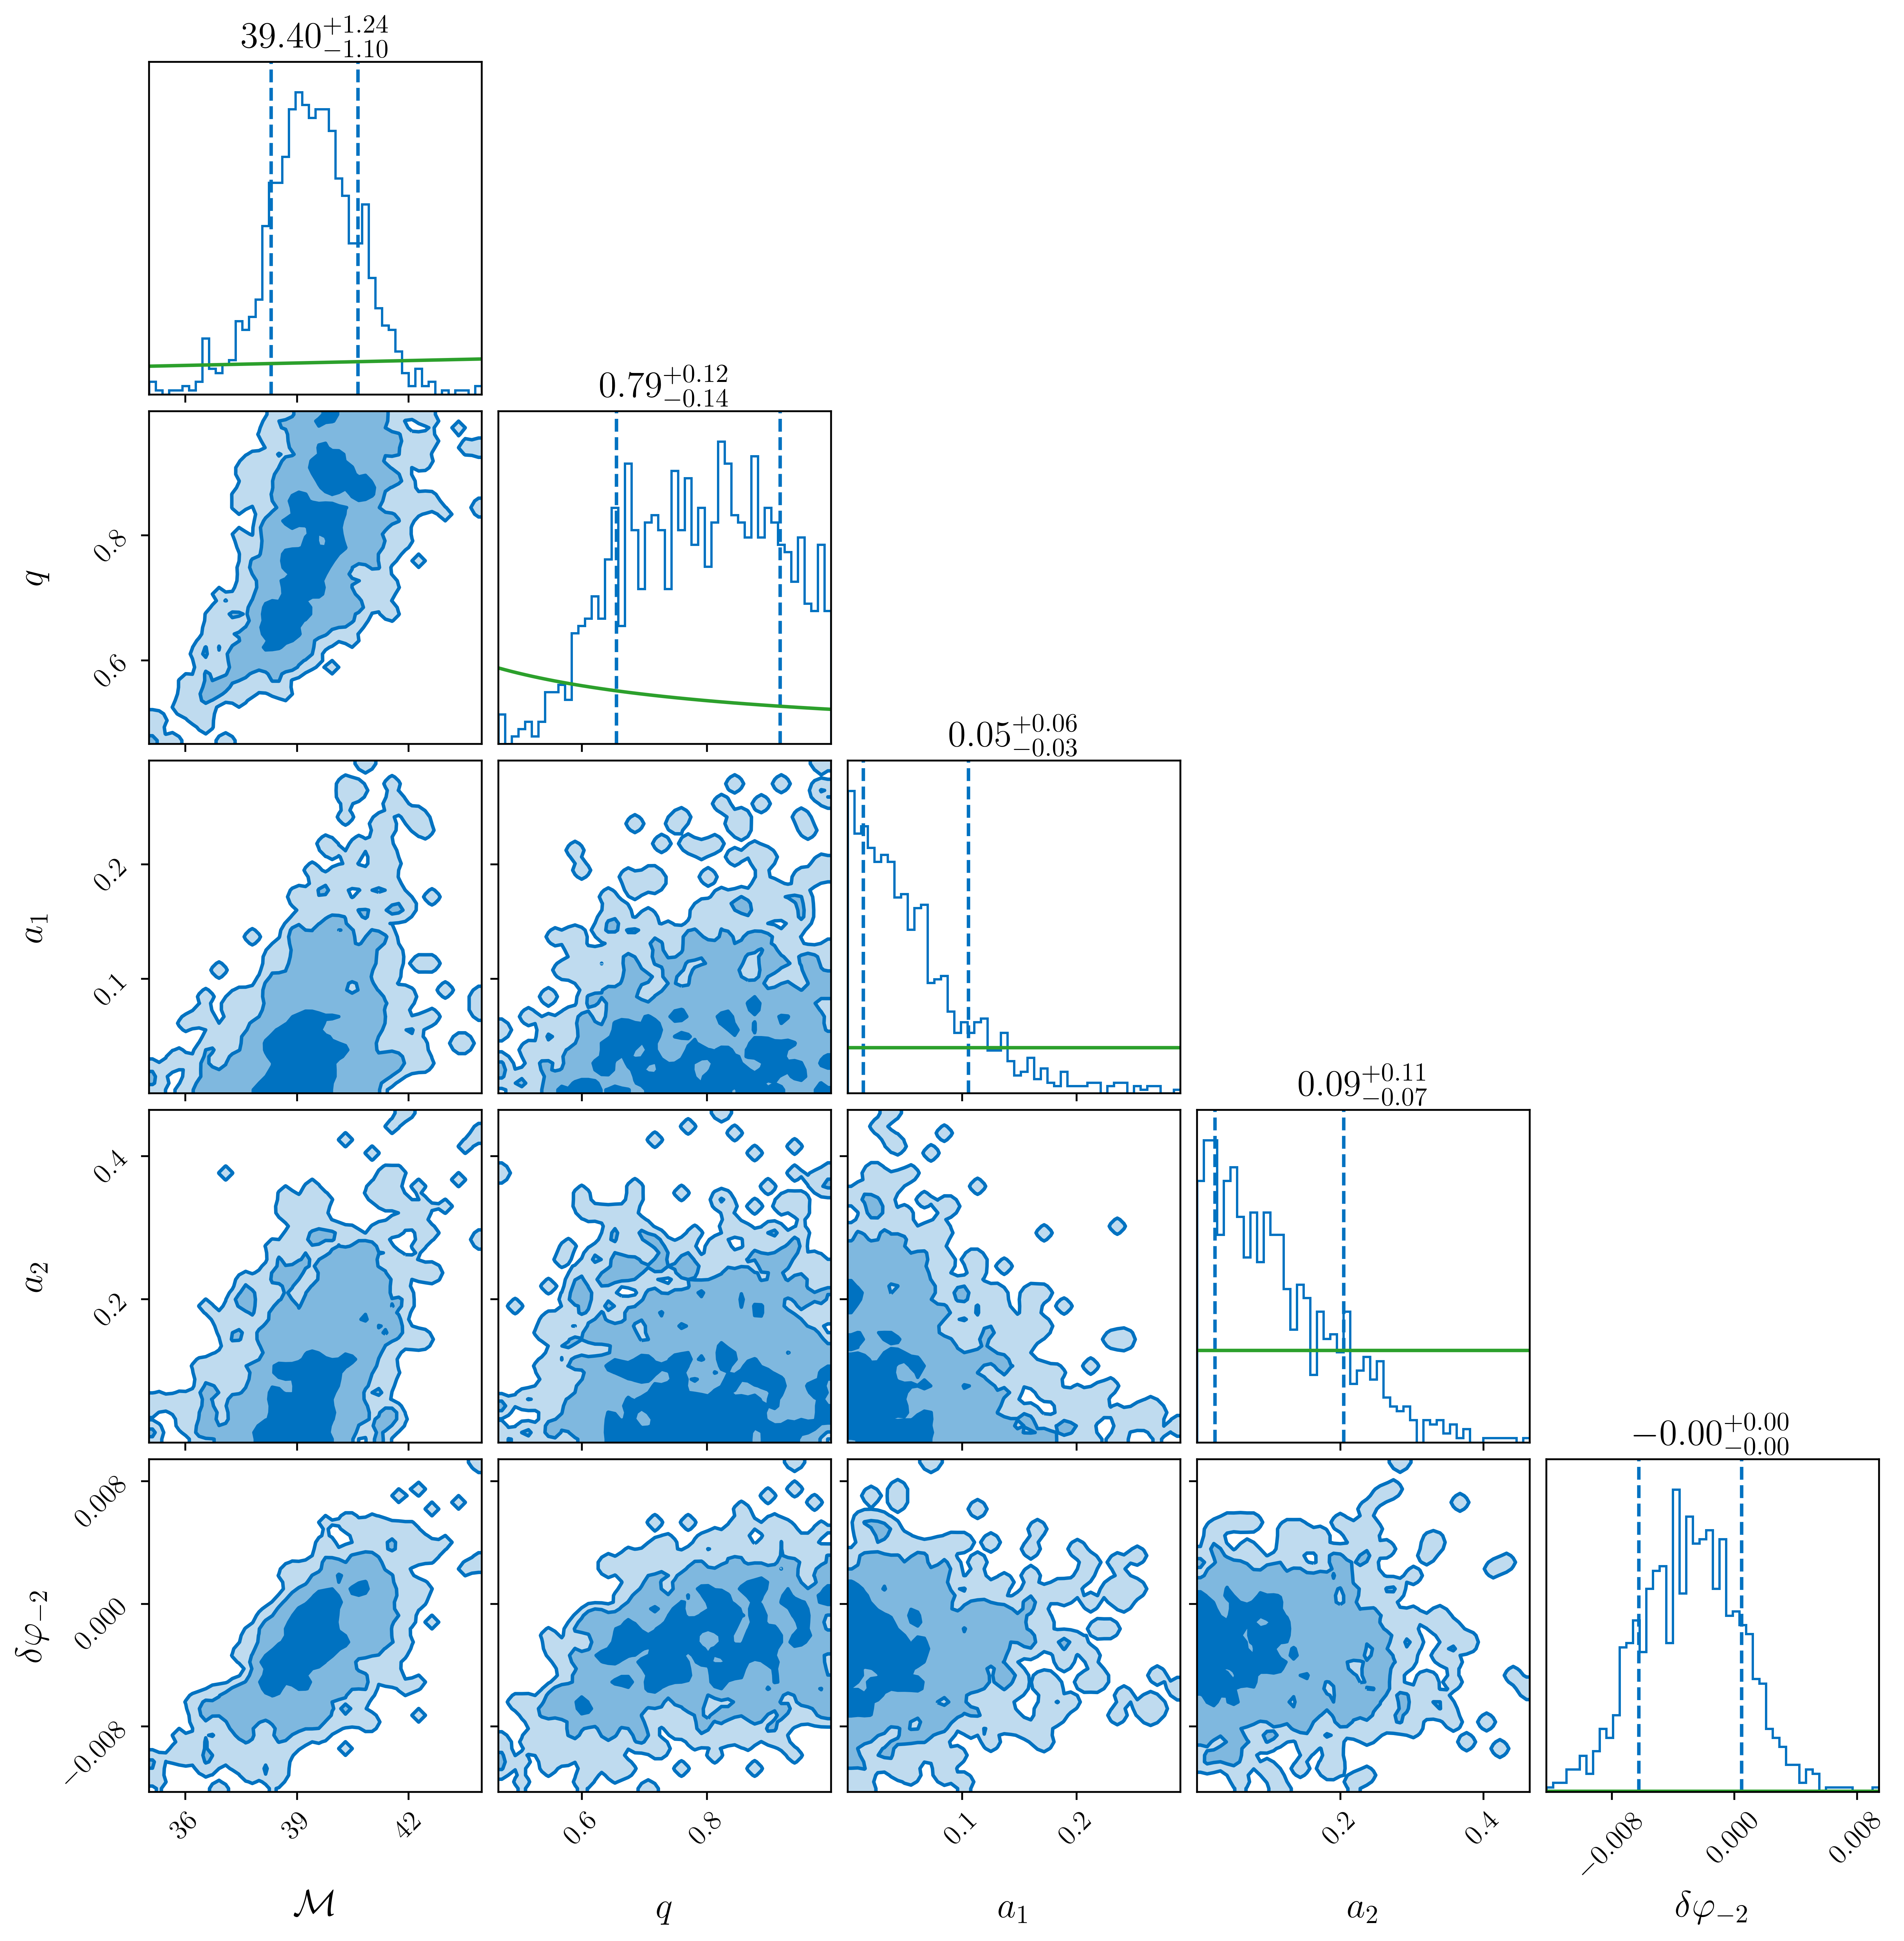

In [14]:
result.plot_corner(
    parameters=["chirp_mass", "mass_ratio", "a_1", "a_2", "dchi_minus2"],
    priors=True,
    filename=f'{outdir}/{label}_corner_plot.pdf',
    labels=[r'$\mathcal{M}$',r'$q$',r'$a_1$',r'$a_2$',r'$\delta \varphi_{-2}$'],
    dpi=500
    )

Clearly, the posteriors are under-resolved. However, we've still managed to recover sensible parameters from our signal. We can run a similar analysis on HPC clusters using ```bilby_pipe```, where we can throw extra computing power at this task to enable the use of production quality settings.

Finally, let's estimate the PDF of $\delta\psi_{-2}$ using kernel density estimation.

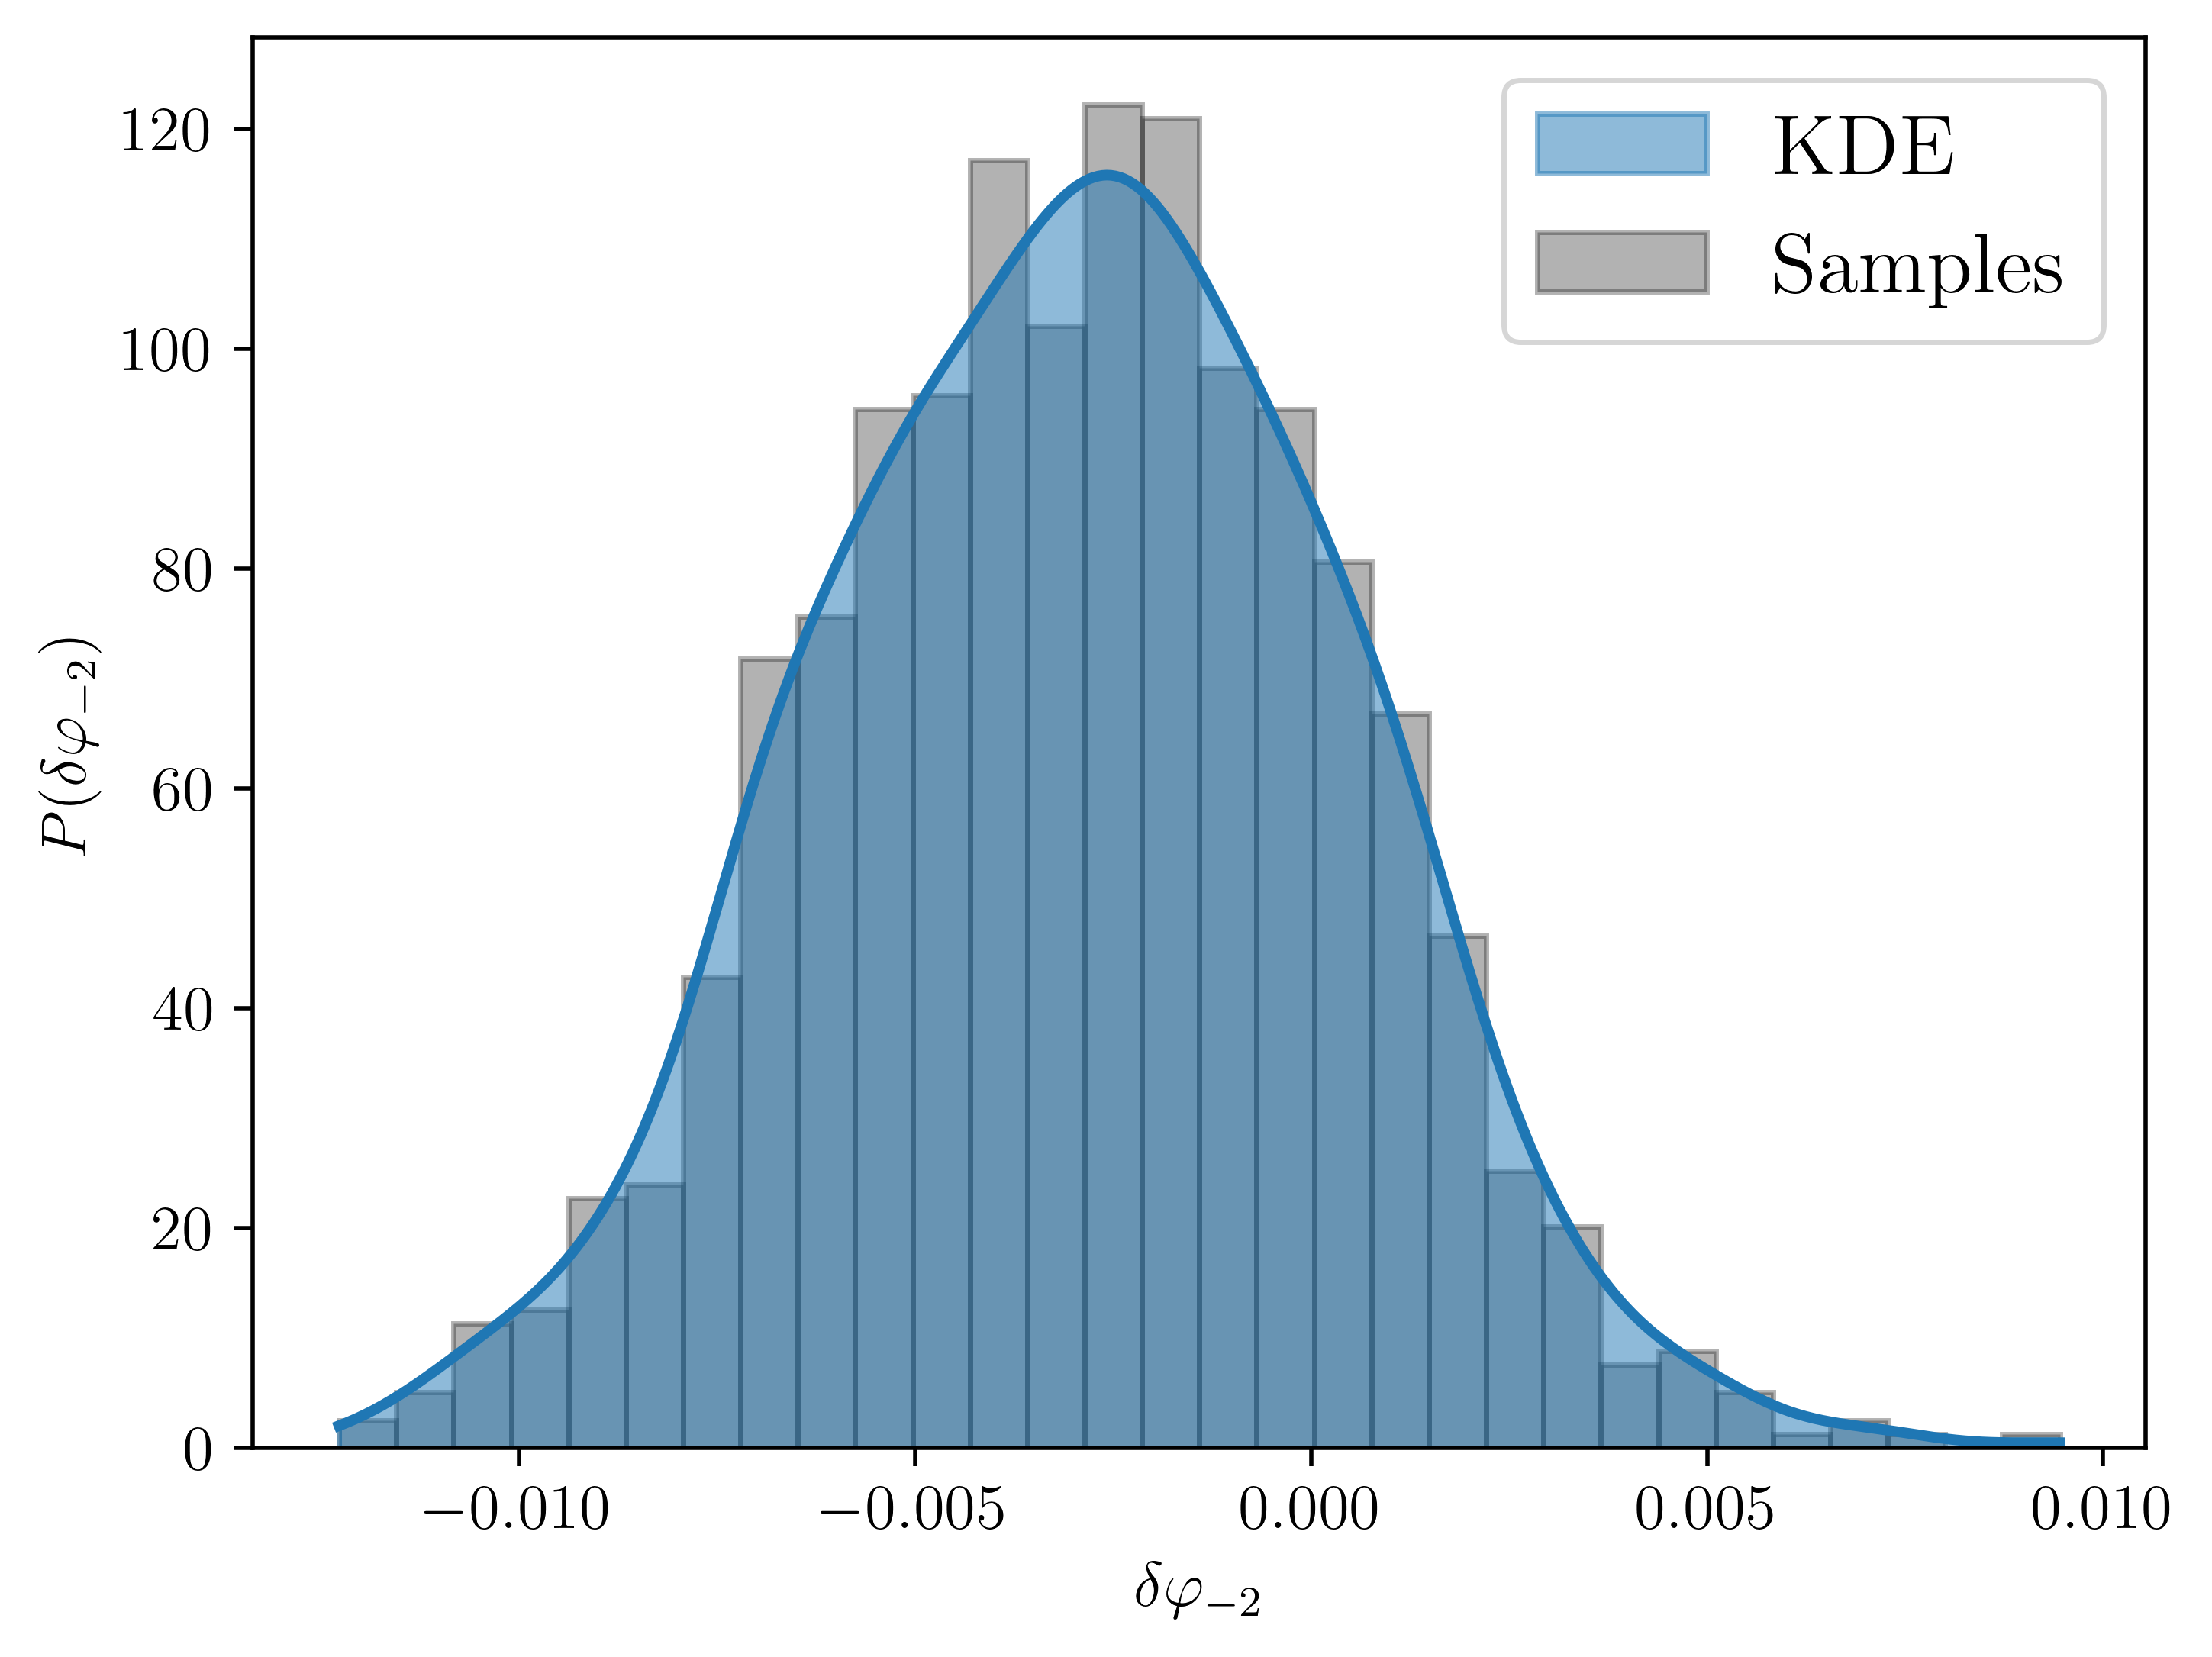

In [15]:
hist = plt.hist(result.posterior["dchi_minus2"], bins=30, density=True, color='k', alpha=0.3, label='Samples')
plt.xlabel(r'$\delta \varphi_{-2}$')
plt.ylabel(r'$P(\delta \varphi_{-2})$')

# Overlay KDE as an approximation to the posterior distribution

from scipy.stats import gaussian_kde

samples = result.posterior["dchi_minus2"]

kde = gaussian_kde(samples)
x_grid = np.linspace(samples.min(), samples.max(), 400)

plt.plot(x_grid, kde(x_grid), color='C0', lw=2)
kde_plot = plt.fill_between(x_grid, kde(x_grid), alpha=0.5, color='C0', label='KDE')

plt.legend(handles=[kde_plot, hist[2][0]])
plt.savefig(f'{outdir}/{label}_1D_marginal_dchi_minus2.pdf')